# 03 · Matrix factorization (explicit ratings, ALS)

## Goal
Train our first collaborative-filtering model and see how much it improves on the baselines from notebook 02.

## The model
Predicted rating = `μ + b_user + b_item + p_user · q_item`
- `μ`: global average rating
- `b_user`, `b_item`: how generous a user is / how well-liked a movie is overall
- `p_user`, `q_item`: k-dimensional **latent vectors**; their dot product captures taste-specific affinity

## How it's trained: ALS
Alternating Least Squares. With the item side fixed, each user's parameters are a small ridge regression with an exact solution. Then we fix the users and solve for every item, and repeat. No learning rate to tune, and every step is guaranteed not to increase the training loss.

## What to expect (read before running)
This model is trained to **predict ratings**, but we judge it by **ranking**. Those aren't the same task. Models fitted on explicit ratings often rank *worse* than plain popularity at top-10, because they never learn which movies users *choose to watch* (only how they rate what they chose). If that happens, it isn't a bug. It's the finding that motivates an implicit-feedback model next.

## Plan
1. Bias-only model (k=0): what do latent factors add?
2. Full MF, tracking RMSE and ranking metrics per iteration
3. Small sweep over k and λ on **validation**
4. Look inside: nearest-neighbour movies, biases, one user's recommendations
5. One final **test** evaluation, refit on train+val

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # notebooks/ -> project root -> scripts

import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from recutils import load_split, to_sets, rank_topk, evaluate_topk

NAME, K, REL, SEED = "sample_10pct", 10, 4.0, 42

S = load_split(NAME)
train, val, test = S["train"], S["val"], S["test"]
n_users = int(S["user_map"].u.max()) + 1
n_items = int(S["item_map"].i.max()) + 1
print(f"{n_users:,} users | {n_items:,} items | train {len(train):,} | val {len(val):,} | test {len(test):,}")

def seen_matrix(*dfs):
    """Sparse 0/1 matrix of (user, item) pairs the user already has; used to hide them from recommendations."""
    d = pd.concat(dfs)
    return sp.csr_matrix((np.ones(len(d), dtype=np.float32), (d.u.values, d.i.values)),
                         shape=(n_users, n_items))

seen_train = seen_matrix(train)
rel_val = to_sets(val[val.rating >= REL])
print("validation users with >=1 relevant item:", len(rel_val))

20,093 users | 17,241 items | train 2,919,680 | val 137,197 | test 137,197
validation users with >=1 relevant item: 18392


## 1 · The model code

**Half-step.** For one user, let `F` be the matrix of the fixed item vectors for the movies they rated, with a column of ones appended. The ones column makes the user's bias just another coefficient. The target is `rating − μ − item_bias`. The user's `[p_u, b_u]` is the ridge-regression solution:

`[p_u, b_u] = (FᵀF + λ·n·I)⁻¹ Fᵀy`

where `n` is the number of ratings that user has. Scaling λ by `n` is the "ALS-WR" variant: users with few ratings get proportionally more shrinkage, which matters in our heavy-tailed data. The item half-step is identical with the roles swapped.

**Rows with no training ratings** get all-zero parameters, so those movies fall back to `μ + b_user`.

In [17]:
def _half_step(M, X, b, mu, lam):
    """Solve for one side given the other.
    M: CSR (rows to solve x fixed side) of ratings | X: fixed vectors | b: fixed biases."""
    n_rows, k = M.shape[0], X.shape[1]
    Xa  = np.hstack([X, np.ones((X.shape[0], 1))])      # [vector, 1]
    out = np.zeros((n_rows, k + 1))                     # [vector, bias]
    eye = np.eye(k + 1)
    indptr, indices, data = M.indptr, M.indices, M.data
    for r in range(n_rows):
        s, e = indptr[r], indptr[r + 1]
        n = e - s
        if n == 0:
            continue
        js = indices[s:e]
        F  = Xa[js]
        y  = data[s:e] - mu - b[js]
        out[r] = np.linalg.solve(F.T @ F + lam * n * eye, F.T @ y)
    return out[:, :k], out[:, k]


def rmse(df, P, Q, bu, bi, mu):
    pred = mu + bu[df.u.values] + bi[df.i.values] + np.einsum("ij,ij->i", P[df.u.values], Q[df.i.values])
    return float(np.sqrt(np.mean((np.clip(pred, 0.5, 5.0) - df.rating.values) ** 2)))


def fit_als(df, k=32, lam=0.1, n_iter=15, eval_fn=None, eval_every=0, rmse_on=val, seed=SEED):
    rng = np.random.default_rng(seed)
    mu  = df.rating.mean()
    R   = sp.csr_matrix((df.rating.values.astype(np.float64), (df.u.values, df.i.values)),
                        shape=(n_users, n_items))
    Rt  = R.T.tocsr()
    Q   = rng.normal(0, 0.1, (n_items, k))
    bi  = np.zeros(n_items)
    hist, t0 = [], time.time()
    for it in range(1, n_iter + 1):
        P, bu = _half_step(R,  Q, bi, mu, lam)     # users given items
        Q, bi = _half_step(Rt, P, bu, mu, lam)     # items given users
        row = {"iter": it, "sec": round(time.time() - t0)}
        if rmse_on is not None:
            row["val_rmse"] = rmse(rmse_on, P, Q, bu, bi, mu)
        if eval_fn and eval_every and (it % eval_every == 0 or it == n_iter):
            row.update(eval_fn(P, Q, bu, bi))
        hist.append(row)
    return {"P": P, "Q": Q, "bu": bu, "bi": bi, "mu": mu}, pd.DataFrame(hist)


def make_eval(rel, seen_csr):
    """Ranking evaluation for a factor model. Ranking score = b_item + p_user·q_item
    (mu and b_user are constant per user, so they can't change that user's order)."""
    def f(P, Q, bu, bi):
        Q32, bi32 = Q.astype(np.float32), bi.astype(np.float32)
        score_fn  = lambda ub: P[ub].astype(np.float32) @ Q32.T + bi32
        return evaluate_topk(rank_topk(score_fn, rel.keys(), seen_csr, K), rel, n_items, K)
    return f

eval_val = make_eval(rel_val, seen_train)

## 2 · Reference points
Three numbers to compare against: predicting the global mean (RMSE floor), the **popularity** ranking from notebook 02, and a **bias-only** model (`k=0`: no latent factors, just `μ + b_user + b_item`). The gap between bias-only and full MF is exactly what the latent vectors contribute.

In [18]:
mu = train.rating.mean()
print("RMSE, predict global mean for everything:", round(float(np.sqrt(((val.rating - mu) ** 2).mean())), 4))

counts = np.bincount(train.i, minlength=n_items).astype(np.float32)
pop_ranked = rank_topk(lambda ub: np.tile(counts, (len(ub), 1)), rel_val.keys(), seen_train, K)
pop = evaluate_topk(pop_ranked, rel_val, n_items, K)

m0, h0 = fit_als(train, k=0, lam=0.1, n_iter=8, eval_fn=eval_val, eval_every=8)
print(h0.tail(1).round(4).to_string(index=False))

results = {"popularity": pop}
results["bias-only (k=0)"] = {**h0.iloc[-1].drop(["iter", "sec"]).to_dict()}
pd.DataFrame(results).T.round(4)

RMSE, predict global mean for everything: 1.0534
 iter  sec  val_rmse  Recall@10  NDCG@10  HitRate@10  Coverage
    8    6    0.8834        0.0      0.0      0.0001    0.0008


,Recall@10,NDCG@10,HitRate@10,Coverage,val_rmse
popularity,0.0574,0.0415,0.1620,0.0137,NaN
bias-only (k=0),0.0000,0.0000,0.0001,0.0008,0.8834


## 3 · Train matrix factorization (k=32, λ=0.1)
`val_rmse` is logged every iteration. Ranking metrics are computed every 3 iterations because they're slower. Watch for the point where RMSE stops improving, which tells us whether 15 iterations is enough. Expect about 1 to 2 minutes.

In [19]:
m1, h1 = fit_als(train, k=32, lam=0.1, n_iter=15, eval_fn=eval_val, eval_every=3)
h1.round(4)

,iter,sec,val_rmse,Recall@10,NDCG@10,HitRate@10,Coverage
0,1,2,0.8946,NaN,NaN,NaN,NaN
1,2,4,0.8707,NaN,NaN,NaN,NaN
2,3,6,0.8512,0.0001,0.0001,0.0004,0.0446
3,4,12,0.8429,NaN,NaN,NaN,NaN
4,5,14,0.8390,NaN,NaN,NaN,NaN
5,6,16,0.8372,0.0003,0.0002,0.0011,0.0620
6,7,22,0.8362,NaN,NaN,NaN,NaN
7,8,24,0.8356,NaN,NaN,NaN,NaN
8,9,26,0.8352,0.0004,0.0002,0.0015,0.0670
9,10,32,0.8349,NaN,NaN,NaN,NaN


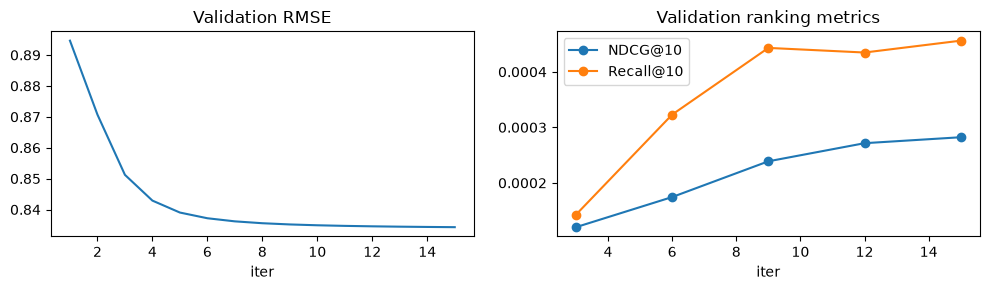

,Recall@10,NDCG@10,HitRate@10,Coverage,val_rmse
popularity,0.0574,0.0415,0.1620,0.0137,NaN
bias-only (k=0),0.0000,0.0000,0.0001,0.0008,0.8834
"MF k=32, λ=0.1",0.0005,0.0003,0.0016,0.0718,NaN


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
h1.plot(x="iter", y="val_rmse", ax=ax[0], title="Validation RMSE"); ax[0].legend().remove()
h1.dropna(subset=["NDCG@10"]).plot(x="iter", y=["NDCG@10", "Recall@10"], ax=ax[1], marker="o", title="Validation ranking metrics")
plt.tight_layout(); plt.show()

results["MF k=32, λ=0.1"] = h1.iloc[-1].drop(["iter", "sec", "val_rmse"]).to_dict()
pd.DataFrame(results).T.round(4)

## 4 · Small hyperparameter sweep (validation only)
- **k** (number of latent factors): too small underfits, too large memorises.
- **λ** (regularization strength): the knob that matters most with so few ratings per movie.

We pick by **validation NDCG@10**, never by test. Each run takes ~1 to 2 minutes, so the whole sweep is about 10 minutes.

In [21]:
grid = [(32, 0.05), (32, 0.2), (16, 0.1), (64, 0.1)]     # (32, 0.1) already done above
rows = [{"k": 32, "lam": 0.1, "val_rmse": h1.val_rmse.iloc[-1],
         **h1.iloc[-1][["Recall@10", "NDCG@10", "HitRate@10", "Coverage"]].to_dict()}]

for k, lam in grid:
    t = time.time()
    mdl, h = fit_als(train, k=k, lam=lam, n_iter=15, eval_fn=eval_val, eval_every=15)
    rows.append({"k": k, "lam": lam, "val_rmse": h.val_rmse.iloc[-1],
                 **h.iloc[-1][["Recall@10", "NDCG@10", "HitRate@10", "Coverage"]].to_dict()})
    print(f"k={k:>3} λ={lam}: done in {time.time()-t:.0f}s")

sweep = pd.DataFrame(rows).sort_values("NDCG@10", ascending=False)
sweep.round(4)

k= 32 λ=0.05: done in 34s
k= 32 λ=0.2: done in 34s
k= 16 λ=0.1: done in 24s
k= 64 λ=0.1: done in 61s


,k,lam,val_rmse,Recall@10,NDCG@10,HitRate@10,Coverage
1,32,0.05,0.8314,0.0015,0.0009,0.0054,0.2635
4,64,0.10,0.8337,0.0006,0.0004,0.0023,0.0681
0,32,0.10,0.8343,0.0005,0.0003,0.0016,0.0718
3,16,0.10,0.8351,0.0003,0.0002,0.0010,0.0740
2,32,0.20,0.8757,0.0000,0.0000,0.0002,0.0037


## 5 · What did the model learn?
Latent features have no labels, but we can test whether they mean anything:
- **Nearest neighbours in factor space**: movies whose `q` vectors point the same way (cosine similarity). Restricted to movies with ≥ 50 training ratings, since vectors for rarely-rated movies are too noisy.
- **Item biases**: the best and worst movies *after* accounting for who watched them.
- **One user's recommendations** next to what they liked in training.

In [22]:
movies   = pd.read_parquet(Path("../data/interim") / NAME / "movies.parquet")
meta     = S["item_map"].merge(movies, on="movieId", how="left").set_index("i").sort_index()
n_train  = np.bincount(train.i, minlength=n_items)
Q, bi    = m1["Q"], m1["bi"]
Qn       = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-9)

def similar(title_part, n=6, min_count=50):
    i = meta.index[meta.title.str.contains(title_part, regex=False)][0]
    sims = Qn @ Qn[i]
    sims[n_train < min_count] = -1
    sims[i] = -1
    top = np.argsort(-sims)[:n]
    print(f"\nClosest to: {meta.loc[i, 'title']}")
    return meta.loc[top, ["title", "genres"]].assign(cosine=sims[top].round(3))

similar("Toy Story (1995)")


Closest to: Toy Story (1995)


,title,genres,cosine
i,,,
2817,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.961
10903,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.906
4396,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.880
5650,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.867
2116,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.863
7261,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,0.861


In [23]:
similar("Matrix, The (1999)")


Closest to: Matrix, The (1999)


,title,genres,cosine
i,,,
2675,Fight Club (1999),Action|Crime|Drama|Thriller,0.666
3584,Unbreakable (2000),Drama|Sci-Fi,0.654
8204,Sin City (2005),Action|Crime|Film-Noir|Mystery|Thriller,0.646
4880,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,0.633
339,"Crow, The (1994)",Action|Crime|Fantasy|Thriller,0.628
31,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,0.617


In [24]:
similar("Pulp Fiction")


Closest to: Pulp Fiction (1994)


,title,genres,cosine
i,,,
1012,Reservoir Dogs (1992),Crime|Mystery|Thriller,0.947
730,Trainspotting (1996),Comedy|Crime|Drama,0.862
6062,Kill Bill: Vol. 1 (2003),Action|Crime|Thriller,0.860
1124,Full Metal Jacket (1987),Drama|War,0.854
6519,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller,0.847
10078,"Wrestler, The (2008)",Drama,0.846


In [25]:
tmp = meta.assign(item_bias=bi, n_train=n_train)
tmp = tmp[tmp.n_train >= 200]
print("Highest item bias:"); display(tmp.nlargest(8, "item_bias")[["title", "item_bias", "n_train"]].round(3))
print("Lowest item bias:");  display(tmp.nsmallest(8, "item_bias")[["title", "item_bias", "n_train"]].round(3))

Highest item bias:


,title,item_bias,n_train
i,,,
14958,Band of Brothers (2001),0.829,261
14455,Planet Earth (2006),0.811,247
305,"Shawshank Redemption, The (1994)",0.702,9747
803,"Godfather, The (1972)",0.609,6217
1106,12 Angry Men (1957),0.604,1998
49,"Usual Suspects, The (1995)",0.581,6301
14588,Your Name. (2016),0.573,327
16131,Parasite (2019),0.563,968


Lowest item bias:


,title,item_bias,n_train
i,,,
3219,Battlefield Earth (2000),-1.593,492
5742,Dumb and Dumberer: When Harry Met Lloyd (2003),-1.522,202
171,Mighty Morphin Power Rangers: The Movie (1995),-1.456,252
1550,Home Alone 3 (1997),-1.409,341
1420,Speed 2: Cruise Control (1997),-1.400,523
1585,Spice World (1997),-1.366,271
379,Street Fighter (1994),-1.364,254
7049,Catwoman (2004),-1.337,273


In [26]:
def show_user(u, model, n=10):
    P, Q, bi = model["P"], model["Q"], model["bi"]
    s = P[u] @ Q.T + bi
    s[seen_train[u].indices] = -np.inf
    rec  = np.argsort(-s)[:n]
    held = set(val[(val.u == u) & (val.rating >= REL)].i)
    print("Rated highest in train:")
    for t in meta.loc[train[train.u == u].nlargest(n, "rating").i, "title"]:
        print("  " + t)
    print("\nTop recommendations (✓ = user later rated it ≥ 4 in validation):")
    for i in rec:
        print(("✓ " if i in held else "  ") + meta.loc[i, "title"])

show_user(list(rel_val)[0], m1)

Rated highest in train:
  Blade Runner (1982)
  Emma (1996)
  Shakespeare in Love (1998)
  Doom Generation, The (1995)
  Eat Drink Man Woman (Yin shi nan nu) (1994)
  Election (1999)
  Elizabeth (1998)
  Star Wars: Episode IV - A New Hope (1977)
  Star Wars: Episode V - The Empire Strikes Back (1980)
  Dark City (1998)

Top recommendations (✓ = user later rated it ≥ 4 in validation):
  The Work (2017)
  Choose Me (1984)
  Gett: The Trial of Viviane Amsalem (2014)
  A Royal Christmas (2014)
  Mutual Appreciation (2005)
  Eternity and a Day (Mia aoniotita kai mia mera) (1998)
  Kings & Queen (Rois et reine) (2004)
  Kill Bill: The Whole Bloody Affair (2011)
  Sketches of Frank Gehry (2005)
  Hamlet (Gamlet) (1964)


## 6 · Final test evaluation (run once)
Set `best_k` and `best_lam` from the sweep above. We then **refit on train + validation** (more history per user, standard practice once hyperparameters are fixed) and rank for each user with train + val items hidden. Test data has not influenced anything until now. **Do not tune after looking at this table.**

In [27]:
best_k, best_lam = 32, 0.05          # <- set from the sweep table

full     = pd.concat([train, val])
seen_tv  = seen_matrix(train, val)
rel_test = to_sets(test[test.rating >= REL])

final, _ = fit_als(full, k=best_k, lam=best_lam, n_iter=15, rmse_on=None)
mf_test  = make_eval(rel_test, seen_tv)(final["P"], final["Q"], final["bu"], final["bi"])

counts_tv = np.bincount(full.i, minlength=n_items).astype(np.float32)
pop_test  = evaluate_topk(
    rank_topk(lambda ub: np.tile(counts_tv, (len(ub), 1)), rel_test.keys(), seen_tv, K),
    rel_test, n_items, K)

test_table = pd.DataFrame({"popularity": pop_test, f"MF k={best_k} λ={best_lam}": mf_test}).T.round(4)
test_table

,Recall@10,NDCG@10,HitRate@10,Coverage
popularity,0.0531,0.0393,0.1562,0.0147
MF k=32 λ=0.05,0.0020,0.0012,0.0072,0.2628


k and λ were chosen on validation. The first run of this cell used λ=0.1 by guess; it was rerun with the validation-best λ=0.05. The conclusion didn't change.

In [28]:
# 7 · Why does ranking fail? How popular are the movies we recommend?
P, Q, bi = m1["P"], m1["Q"], m1["bi"]
Q32, bi32 = Q.astype(np.float32), bi.astype(np.float32)

ranked = rank_topk(lambda ub: P[ub].astype(np.float32) @ Q32.T + bi32, rel_val.keys(), seen_train, K)
rec_counts = np.array([n_train[i] for r in ranked.values() for i in r])

print("median train ratings of recommended movies:", int(np.median(rec_counts)))
print("share of recommendations with < 20 train ratings:", round((rec_counts < 20).mean(), 3))
print("median train ratings across the catalogue:", int(np.median(n_train)))

# same model, but only allowed to recommend movies with at least min_n train ratings
for min_n in (20, 100, 500):
    pen = np.where(n_train >= min_n, 0.0, -1e9).astype(np.float32)
    r = evaluate_topk(rank_topk(lambda ub: P[ub].astype(np.float32) @ Q32.T + bi32 + pen,
                                rel_val.keys(), seen_train, K), rel_val, n_items, K)
    print(f"min_n={min_n:>3}:", {k: round(v, 4) for k, v in r.items()})

median train ratings of recommended movies: 6
share of recommendations with < 20 train ratings: 0.834
median train ratings across the catalogue: 23
min_n= 20: {'Recall@10': np.float64(0.0061), 'NDCG@10': np.float64(0.0033), 'HitRate@10': np.float64(0.019), 'Coverage': 0.0693}
min_n=100: {'Recall@10': np.float64(0.0244), 'NDCG@10': np.float64(0.0151), 'HitRate@10': np.float64(0.0762), 'Coverage': 0.0617}
min_n=500: {'Recall@10': np.float64(0.046), 'NDCG@10': np.float64(0.0349), 'HitRate@10': np.float64(0.1413), 'Coverage': 0.0429}


The recommended movies have a median of 6 training ratings against 23 for the catalogue, and 83% of recommendations have fewer than 20. Once you restrict candidates to movies with at least 500 ratings, NDCG@10 goes from 0.0003 to 0.0349, close to popularity’s 0.0415. So most of the damage was rare-movie noise, not a problem with the factors themselves.

In [29]:
Path("../models").mkdir(exist_ok=True)
np.savez("../models/als_explicit.npz", **final)

print("test RMSE:", round(rmse(test, final["P"], final["Q"], final["bu"], final["bi"], final["mu"]), 4))

test RMSE: 0.8417


### Why

Two separate things are going on, and the diagnostic cell pulled them apart.

The first is rare movies. The median movie we recommended has 6 training ratings (the catalogue median is 23), and 83% of recommendations have fewer than 20. A movie with a few high ratings gets a big bias and big factors, so it lands at the top of everyone's list. When we only allow movies with enough ratings, the same model gets much better:

| Candidates allowed | Recall@10 | NDCG@10 | Coverage |
|---|---|---|---|
| All movies | 0.0005 | 0.0003 | 0.072 |
| ≥ 20 train ratings | 0.0061 | 0.0033 | 0.069 |
| ≥ 100 train ratings | 0.0244 | 0.0151 | 0.062 |
| ≥ 500 train ratings | 0.0460 | 0.0349 | 0.043 |
| Popularity (for reference) | 0.0574 | 0.0415 | 0.014 |

(validation, k=32, λ=0.1)

The second is that even at ≥ 500 the model sits below popularity. It's trained to predict how someone rates a movie they already watched. It never sees which movies they chose to watch, and that choice is most of what the held-out ratings reflect. Popularity captures it directly. Restricting the candidates helps, but it doesn't teach the model that.

We need to fix the rare-movie problem inside the model instead of filtering afterwards (stronger shrinkage on the item side). A minimum-count filter is a stopgap, and if we keep one, its threshold has to be picked on validation, not test.